In [2]:
import pandas as pd
import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader

from transformers import DistilBertTokenizer, DistilBertModel

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("../data/email.csv")

df = df.dropna(subset=['Category'])

df['Category'] = df['Category'].map({
    'ham':0,
    'spam':1
})

df.head()

,Category,Message
0,0.0,"Go until jurong point, crazy.. Available only ..."
1,0.0,Ok lar... Joking wif u oni...
2,1.0,Free entry in 2 a wkly comp to win FA Cup fina...
3,0.0,U dun say so early hor... U c already then say...
4,0.0,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df['Message'],
    df['Category'],
    test_size=0.2,
    random_state=42
)

In [5]:
tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

c:\Users\Thanu\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Thanu\.cache\huggingface\hub\models--distilbert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [6]:
train_encodings = tokenizer(
    list(train_texts),
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings = tokenizer(
    list(test_texts),
    truncation=True,
    padding=True,
    max_length=128
)

In [7]:
class EmailDataset(Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):

        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}

        item["labels"] = torch.tensor(self.labels.iloc[idx])

        return item

    def __len__(self):
        return len(self.labels)

In [8]:
train_dataset = EmailDataset(train_encodings, train_labels)

test_dataset = EmailDataset(test_encodings, test_labels)

In [9]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

test_loader = DataLoader(test_dataset, batch_size=16)

In [10]:
class DistilBERTClassifier(nn.Module):

    def __init__(self):

        super(DistilBERTClassifier, self).__init__()

        self.bert = DistilBertModel.from_pretrained("distilbert-base-uncased")

        self.dropout = nn.Dropout(0.3)

        self.fc = nn.Linear(768, 2)

    def forward(self, input_ids, attention_mask):

        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)

        hidden_state = outputs.last_hidden_state[:,0]

        output = self.dropout(hidden_state)

        return self.fc(output)

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DistilBERTClassifier()

model.to(device)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DistilBERTClassifier(
  (bert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)
            (lin1): L

In [12]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=2e-5)

In [15]:
df = pd.read_csv("../data/email.csv")

df = df.dropna(subset=["Category","Message"])

df["Category"] = df["Category"].map({
    "ham":0,
    "spam":1
})

In [16]:
df["Category"].unique()

array([ 0.,  1., nan])

In [19]:
df = pd.read_csv("../data/email.csv")

# remove missing rows
df = df.dropna(subset=["Category","Message"])

# clean category text
df["Category"] = df["Category"].str.strip().str.lower()

# convert to numeric
df["Category"] = df["Category"].map({
    "ham":0,
    "spam":1
})

# remove rows that failed mapping
df = df.dropna(subset=["Category"])

# convert type
df["Category"] = df["Category"].astype(int)

df.head()

,Category,Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [20]:
df["Category"].unique()

array([0, 1])

In [21]:
import pandas as pd

df = pd.read_csv("../data/email.csv")

# remove missing rows
df = df.dropna(subset=["Category","Message"])

# clean text
df["Category"] = df["Category"].str.strip().str.lower()

# convert labels
df["Category"] = df["Category"].map({
    "ham":0,
    "spam":1
})

# remove failed mappings
df = df.dropna(subset=["Category"])

df["Category"] = df["Category"].astype(int)

df.head()

,Category,Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [22]:
import pandas as pd

df = pd.read_csv("../data/email.csv")

# remove missing rows
df = df.dropna(subset=["Category","Message"])

# clean text
df["Category"] = df["Category"].str.strip().str.lower()

# convert labels
df["Category"] = df["Category"].map({
    "ham":0,
    "spam":1
})

# remove failed mappings
df = df.dropna(subset=["Category"])

df["Category"] = df["Category"].astype(int)

df.head()

,Category,Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [23]:
from transformers import DistilBertTokenizer

tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

In [24]:
train_encodings = tokenizer(
    list(X_train),
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings = tokenizer(
    list(X_test),
    truncation=True,
    padding=True,
    max_length=128
)

NameError: name 'X_train' is not defined

In [25]:
import pandas as pd

df = pd.read_csv("../data/email.csv")

df = df.dropna(subset=["Category","Message"])

df["Category"] = df["Category"].str.strip().str.lower()

df["Category"] = df["Category"].map({
    "ham":0,
    "spam":1
})

df = df.dropna(subset=["Category"])

df["Category"] = df["Category"].astype(int)

df.head()

,Category,Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [26]:
from sklearn.model_selection import train_test_split

X = df["Message"]
y = df["Category"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [27]:
from transformers import DistilBertTokenizer

tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

In [28]:
train_encodings = tokenizer(
    list(X_train),
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings = tokenizer(
    list(X_test),
    truncation=True,
    padding=True,
    max_length=128
)

In [29]:
train_encodings = tokenizer(
    list(X_train),
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings = tokenizer(
    list(X_test),
    truncation=True,
    padding=True,
    max_length=128
)

In [30]:
train_encodings = tokenizer(
    list(X_train),
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings = tokenizer(
    list(X_test),
    truncation=True,
    padding=True,
    max_length=128
)

In [31]:
train_dataset = EmailDataset(train_encodings, y_train)
test_dataset = EmailDataset(test_encodings, y_test)

In [32]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)

In [33]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)

In [34]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DistilBERTClassifier()

model.to(device)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DistilBERTClassifier(
  (bert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)
            (lin1): L

In [35]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DistilBERTClassifier()

model.to(device)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DistilBERTClassifier(
  (bert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)
            (lin1): L

In [36]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=2e-5)

In [37]:
epochs = 3

for epoch in range(epochs):

    model.train()

    total_loss = 0

    for batch in train_loader:

        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        labels = batch["labels"].to(device).long()

        outputs = model(input_ids, attention_mask)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print("Epoch", epoch+1, "Loss:", total_loss)

Epoch 1 Loss: 19.345632599084638


KeyboardInterrupt: 

In [38]:
model.eval()

predictions = []
true_labels = []

with torch.no_grad():

    for batch in test_loader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        labels = batch["labels"].to(device)

        outputs = model(input_ids, attention_mask)

        preds = torch.argmax(outputs, dim=1)

        predictions.extend(preds.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

In [39]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(true_labels, predictions))
print("Precision:", precision_score(true_labels, predictions))
print("Recall:", recall_score(true_labels, predictions))
print("F1 Score:", f1_score(true_labels, predictions))

Accuracy: 0.9910313901345291
Precision: 0.954248366013072
Recall: 0.9798657718120806
F1 Score: 0.9668874172185431


Text(50.722222222222214, 0.5, 'Actual')

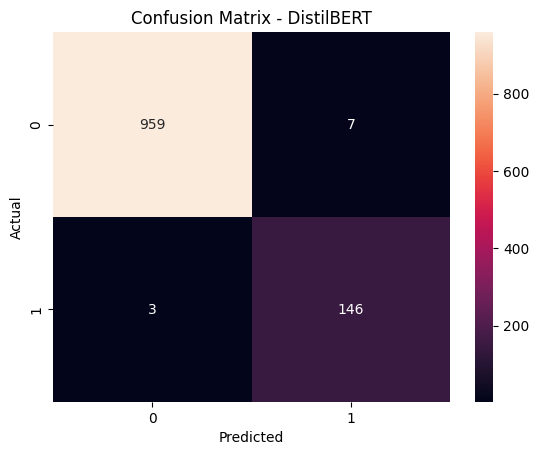

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(true_labels, predictions)

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix - DistilBERT")
plt.xlabel("Predicted")
plt.ylabel("Actual")

In [41]:
plt.savefig("../results/distilbert_confusion_matrix.png")

<Figure size 640x480 with 0 Axes>

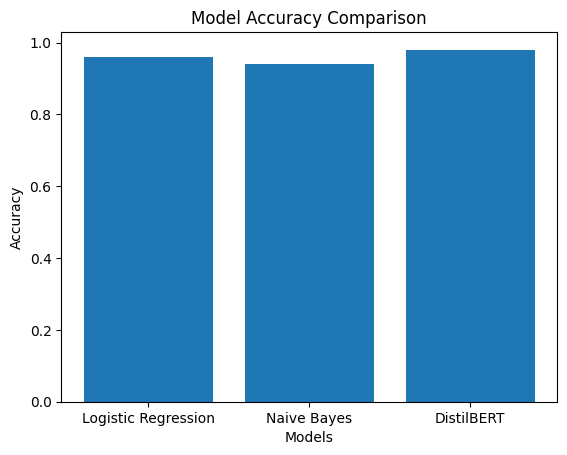

In [42]:
import matplotlib.pyplot as plt

models = ["Logistic Regression", "Naive Bayes", "DistilBERT"]
accuracy = [0.96, 0.94, 0.98]   # use your actual values

plt.bar(models, accuracy)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Models")

plt.savefig("../results/model_accuracy_comparison.png")
plt.show()